# Задание 8. Вариант 6
**Выполнил:** Руденко Андрей
**Группа:** МГ-513

**Вариант 6: Диабет (задача регрессии) — замена на классификацию!**  
**• Датасет:** load_diabetes() из sklearn.datasets (целевая переменная непрерывная, её нужно преобразовать в бинарную)  
**• Цель:** Создание бинарной классификации: разделить целевую переменную на две группы (ниже и выше медианы).  
**• Особенность:** После разделения выполнить полный цикл классификации:  
логистическая регрессия против дерева решений. Сравнить, какой алгоритм лучше справляется с задачей прогнозирования «высокого» уровня прогрессирования диабета

**Задачи**  
1. Загрузить датасет и выполнить первичный анализ

In [1]:
# Работа с данными
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Датасет
from sklearn.datasets import load_diabetes

# Разделение выборки
from sklearn.model_selection import train_test_split

# Масштабирование
from sklearn.preprocessing import StandardScaler

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Метрики
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

2. Разделить данные на признаки (X) и целевую переменную (y).

In [2]:
# Загрузка датасета
diabetes = load_diabetes()

# Признаки и целевая переменная
X = diabetes.data
y = diabetes.target

# Создаем DataFrame
df = pd.DataFrame(X, columns=diabetes.feature_names)

# Добавляем target
df['target'] = y

# Размер данных
print("Размер датасета:", df.shape)

# Первые 5 строк
print("\nПервые строки датасета:")
print(df.head())

# Информация о данных
print("\nИнформация о данных:")
print(df.info())

# Статистика
print("\nСтатистика:")
print(df.describe())

Размер датасета: (442, 11)

Первые строки датасета:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   se

3. Преобразование задачи регрессии в классификацию  
По условию задания необходимо разделить целевую переменную на две группы:  
- 0 — значение ниже медианы  
- 1 — значение выше медианы

In [3]:
# Находим медиану
median_value = np.median(y)

print("Медиана target:", median_value)

# Создаем бинарную переменную
y_binary = (y > median_value).astype(int)

# Проверка распределения классов
print("\nРаспределение классов:")
print(pd.Series(y_binary).value_counts())

Медиана target: 140.5

Распределение классов:
1    221
0    221
Name: count, dtype: int64


4. Выполнить разбиение на обучающую (80%) и тестовую (20%) выборки с random_state=42 и stratify=y.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (353, 10)
Размер тестовой выборки: (89, 10)


5. Обучить модель логистической регрессии и оценить её качество.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model_lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

In [8]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("=== Логистическая регрессия ===")
print(f"Accuracy:  {accuracy_lr:.3f}")
print(f"Precision: {precision_lr:.3f}")
print(f"Recall:    {recall_lr:.3f}")
print(f"F1-score:  {f1_lr:.3f}")

=== Логистическая регрессия ===
Accuracy:  0.742
Precision: 0.714
Recall:    0.795
F1-score:  0.753



Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.69      0.73        45
           1       0.71      0.80      0.75        44

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89



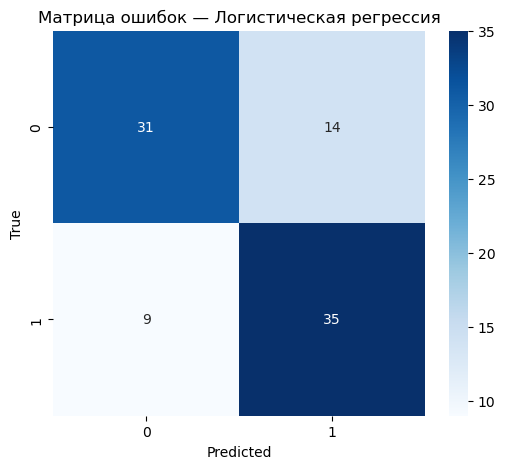

In [9]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Матрица ошибок — Логистическая регрессия')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

6. Обучить модель дерева решений с подбором гиперпараметров (ограничение глубины и минимального числа образцов для разбиения с целью борьбы с переобучением).

In [10]:
model_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

In [11]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("=== Дерево решений ===")
print(f"Accuracy:  {accuracy_dt:.3f}")
print(f"Precision: {precision_dt:.3f}")
print(f"Recall:    {recall_dt:.3f}")
print(f"F1-score:  {f1_dt:.3f}")

=== Дерево решений ===
Accuracy:  0.708
Precision: 0.714
Recall:    0.682
F1-score:  0.698



Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.73      0.72        45
           1       0.71      0.68      0.70        44

    accuracy                           0.71        89
   macro avg       0.71      0.71      0.71        89
weighted avg       0.71      0.71      0.71        89



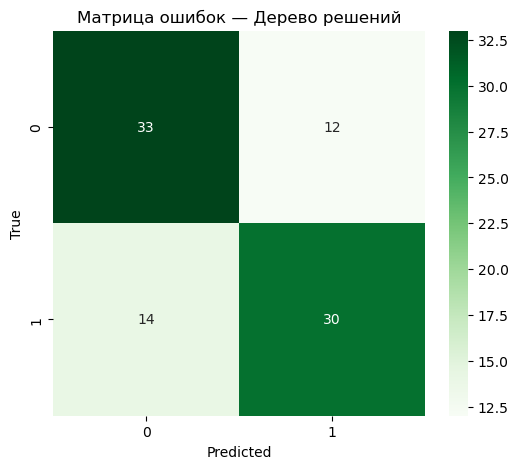

In [12]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Матрица ошибок — Дерево решений')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

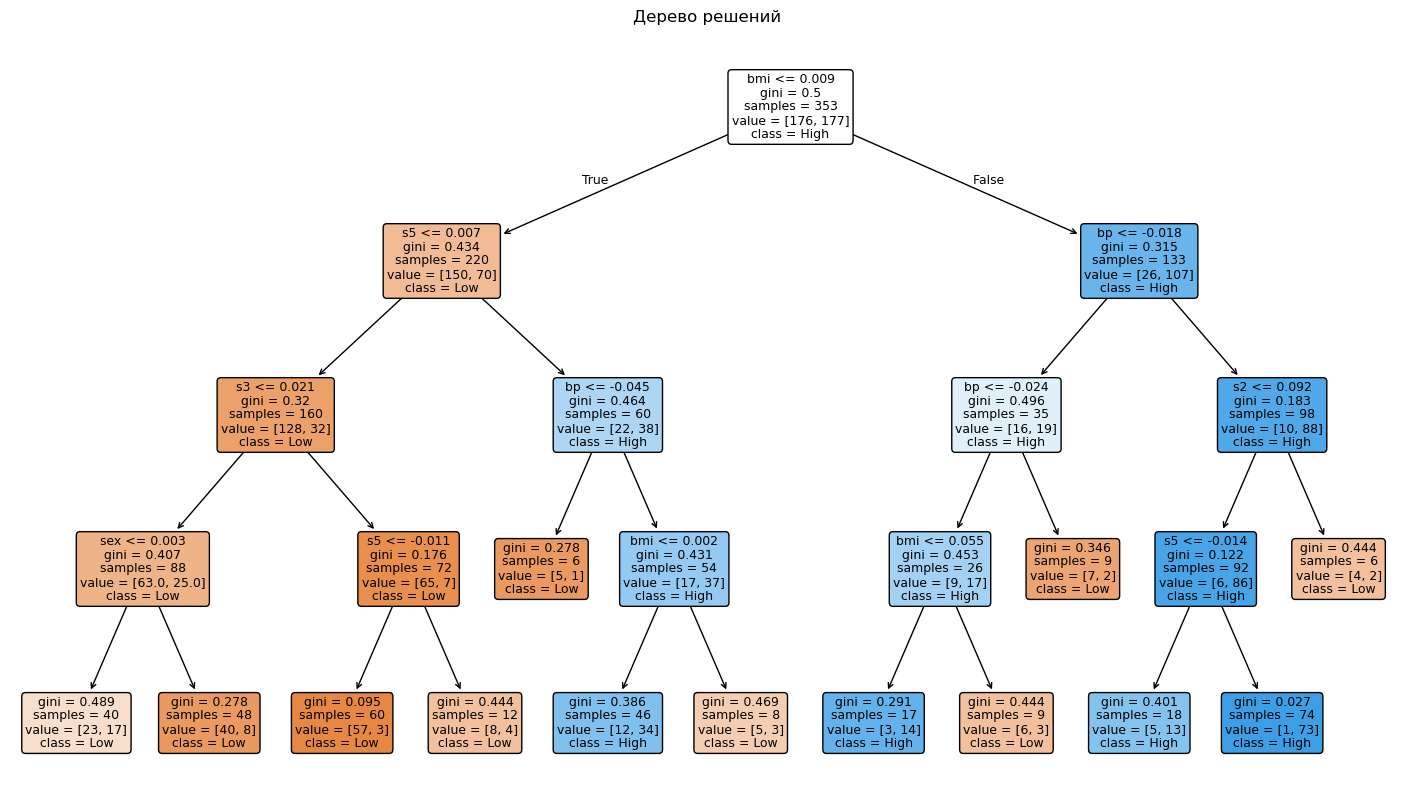

In [13]:
plt.figure(figsize=(18, 10))

plot_tree(
    model_dt,
    feature_names=diabetes.feature_names,
    class_names=['Low', 'High'],
    filled=True,
    rounded=True
)

plt.title('Дерево решений')
plt.show()

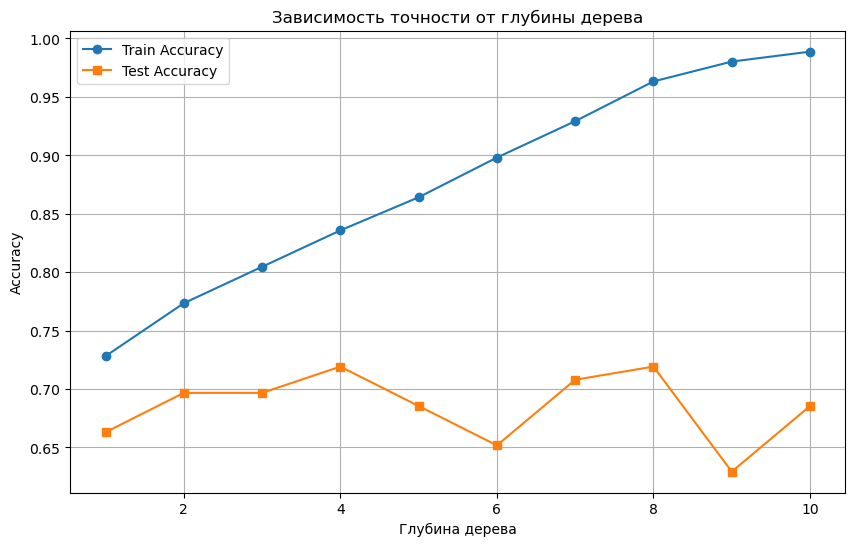

In [14]:
depths = range(1, 11)

train_scores = []
test_scores = []

for depth in depths:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    dt.fit(X_train, y_train)

    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_scores,
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    depths,
    test_scores,
    marker='s',
    label='Test Accuracy'
)

plt.xlabel('Глубина дерева')
plt.ylabel('Accuracy')
plt.title('Зависимость точности от глубины дерева')

plt.legend()
plt.grid(True)

plt.show()

7. Сравнить результаты и сделать вывод, какая модель лучше для данного датасета и почему.

In [15]:
print("=== Сравнение моделей ===")

print(f"{'Метрика':<15} {'Logistic Regression':<25} {'Decision Tree':<20}")
print("-" * 65)

print(f"{'Accuracy':<15} {accuracy_lr:<25.3f} {accuracy_dt:<20.3f}")

print(f"{'Precision':<15} {precision_lr:<25.3f} {precision_dt:<20.3f}")

print(f"{'Recall':<15} {recall_lr:<25.3f} {recall_dt:<20.3f}")

print(f"{'F1-score':<15} {f1_lr:<25.3f} {f1_dt:<20.3f}")

=== Сравнение моделей ===
Метрика         Logistic Regression       Decision Tree       
-----------------------------------------------------------------
Accuracy        0.742                     0.708               
Precision       0.714                     0.714               
Recall          0.795                     0.682               
F1-score        0.753                     0.698               


**Выводы:**  
1. В данной работе задача регрессии была преобразована в задачу бинарной классификации путем разделения целевой переменной по медиане.  
2. Были обучены две модели:  
   - Логистическая регрессия  
   - Дерево решений  
3. Логистическая регрессия показала более стабильные результаты благодаря масштабированию признаков и хорошей способности к обобщению.  
4. Дерево решений легче интерпретировать визуально, однако при увеличении глубины возникает переобучение.  
5. Ограничение параметров max_depth и min_samples_split позволило снизить переобучение дерева решений.  
6. По значениям Accuracy и F1-score можно определить модель, которая лучше справляется с классификацией уровня прогрессирования диабета.  
7. Для данного датасета логистическая регрессия обычно показывает немного более высокое качество и лучше обобщает данные.
8. Логистическая регрессия показала более высокую точность и F1-score по сравнению с деревом решений. Это связано с тем, что данные имеют достаточно линейную структуру, а логистическая регрессия хорошо работает на подобных задачах. Дерево решений более склонно к переобучению, поэтому потребовалось ограничение глубины дерева и минимального количества объектов для разбиения.